In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
# compiling dfs
folder = Path('./output/reconstr_grid2')
# dev = pd.read_csv(folder/'dev.csv')
# test = pd.read_csv(folder/'test.csv')

subfolders = ['t1', 't2', 't3']
dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

# get confs, update
confs = ConfigLookup(
    keys=['encoder_class','method','mlp'],
    configs=dev['config'].unique().tolist(),
    path=folder,
    save=True,
).data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

In [3]:
test

,encoder_class,method,mlp,config,trial,metric,value
0,Linear,node,True,encoderclassLinear_methodNode_mlpTrue,0,loss,0.741007
1,Linear,node,True,encoderclassLinear_methodNode_mlpTrue,0,mse,0.694983
2,Linear,node,True,encoderclassLinear_methodNode_mlpTrue,0,rmse,0.833656
3,Linear,node,True,encoderclassLinear_methodNode_mlpTrue,0,mae,0.564753
4,Linear,node,True,encoderclassLinear_methodNode_mlpTrue,0,r2,0.818224
...,...,...,...,...,...,...,...
6475,GATConv,set,False,encoderclassGATConv_methodSet_mlpFalse,89,mse,0.664720
6476,GATConv,set,False,encoderclassGATConv_methodSet_mlpFalse,89,rmse,0.815304
6477,GATConv,set,False,encoderclassGATConv_methodSet_mlpFalse,89,mae,0.554885
6478,GATConv,set,False,encoderclassGATConv_methodSet_mlpFalse,89,r2,0.824162


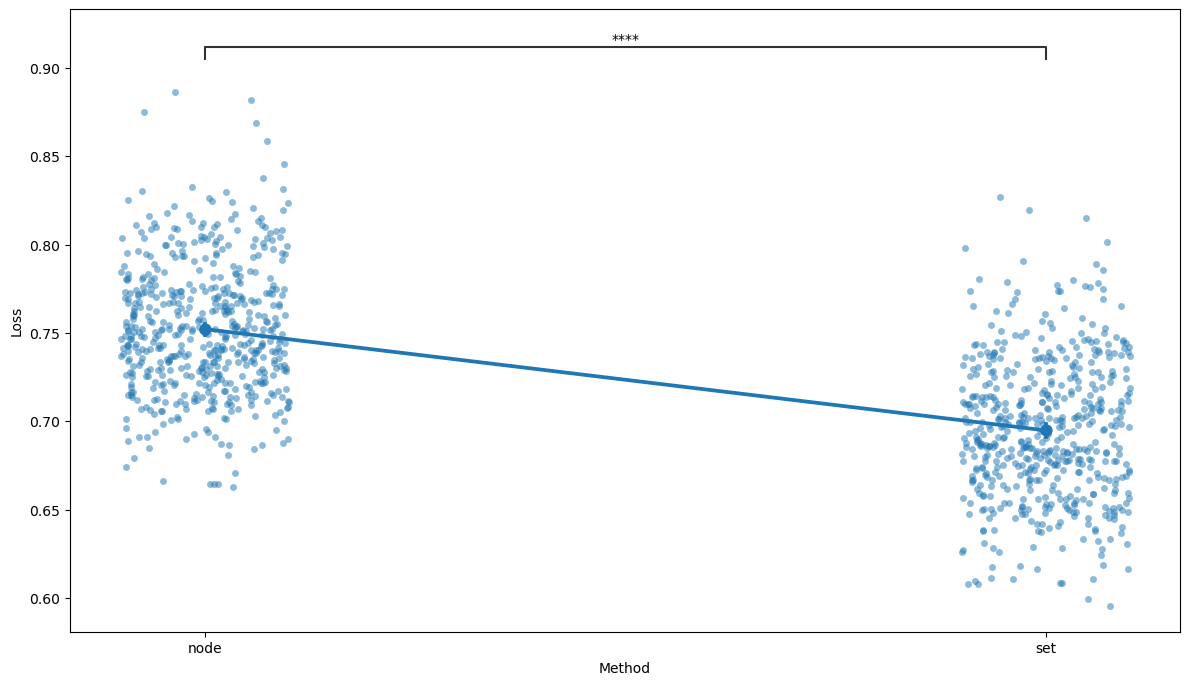

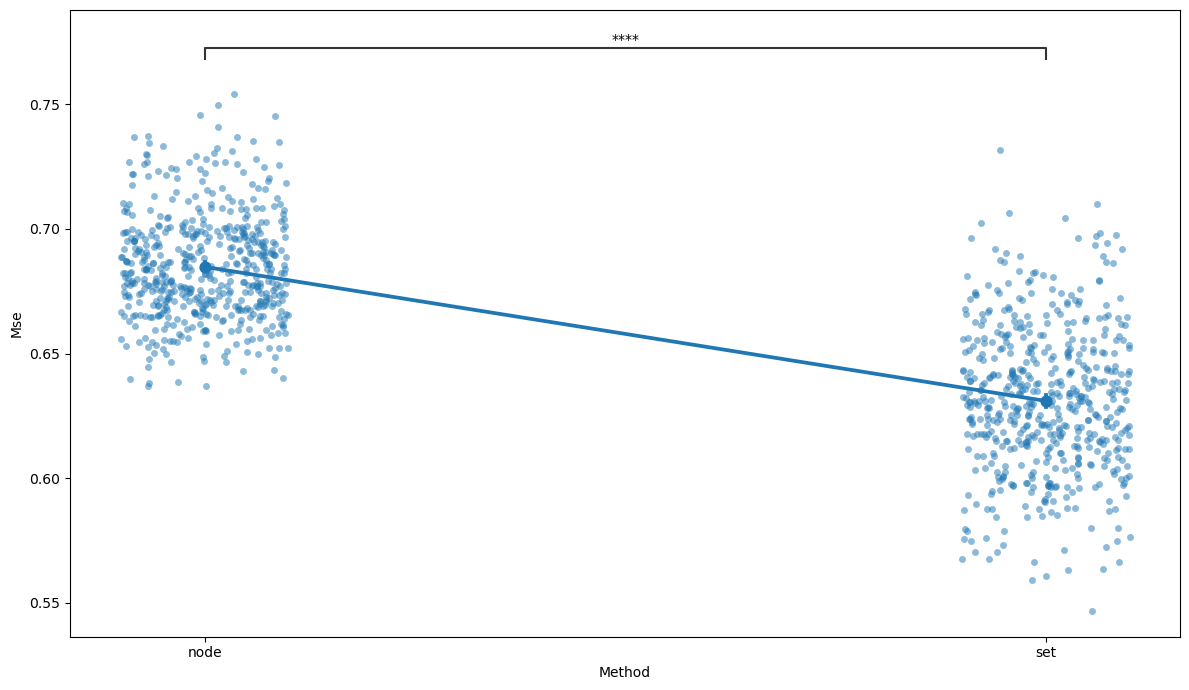

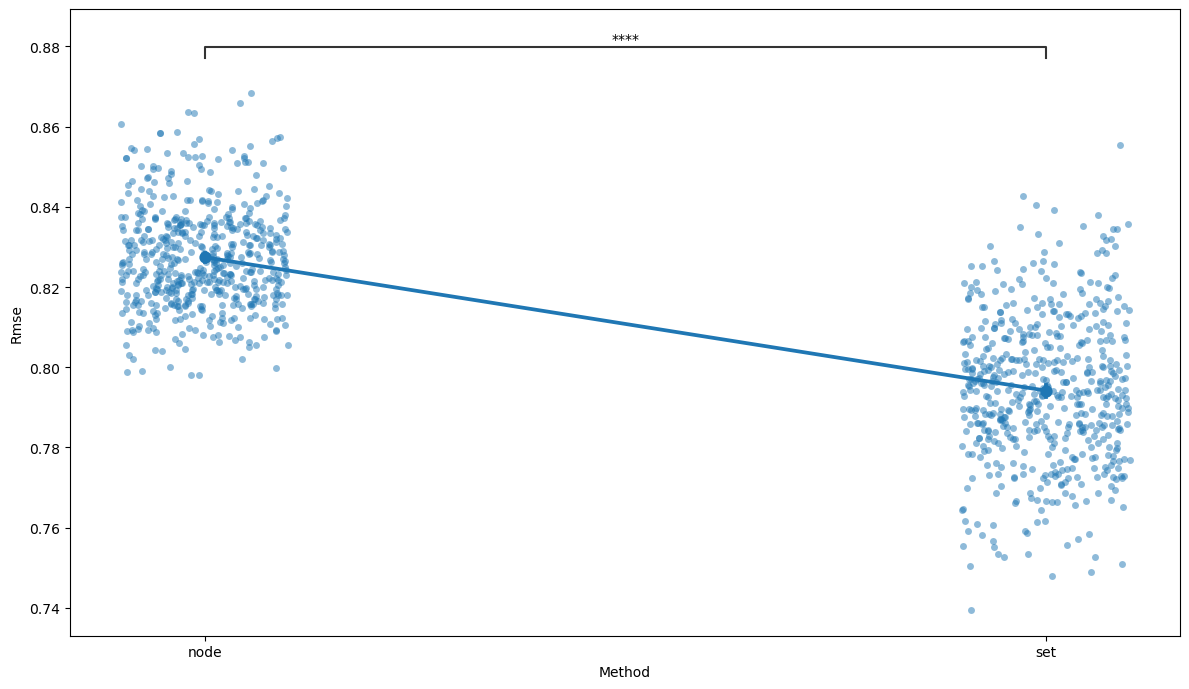

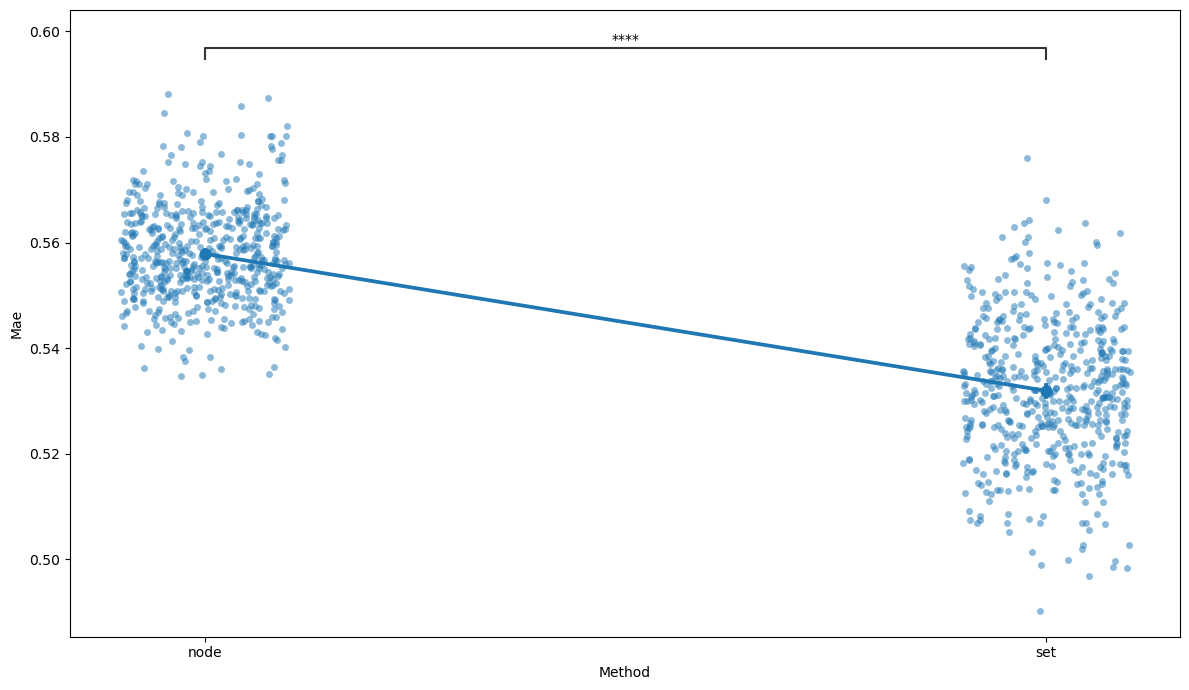

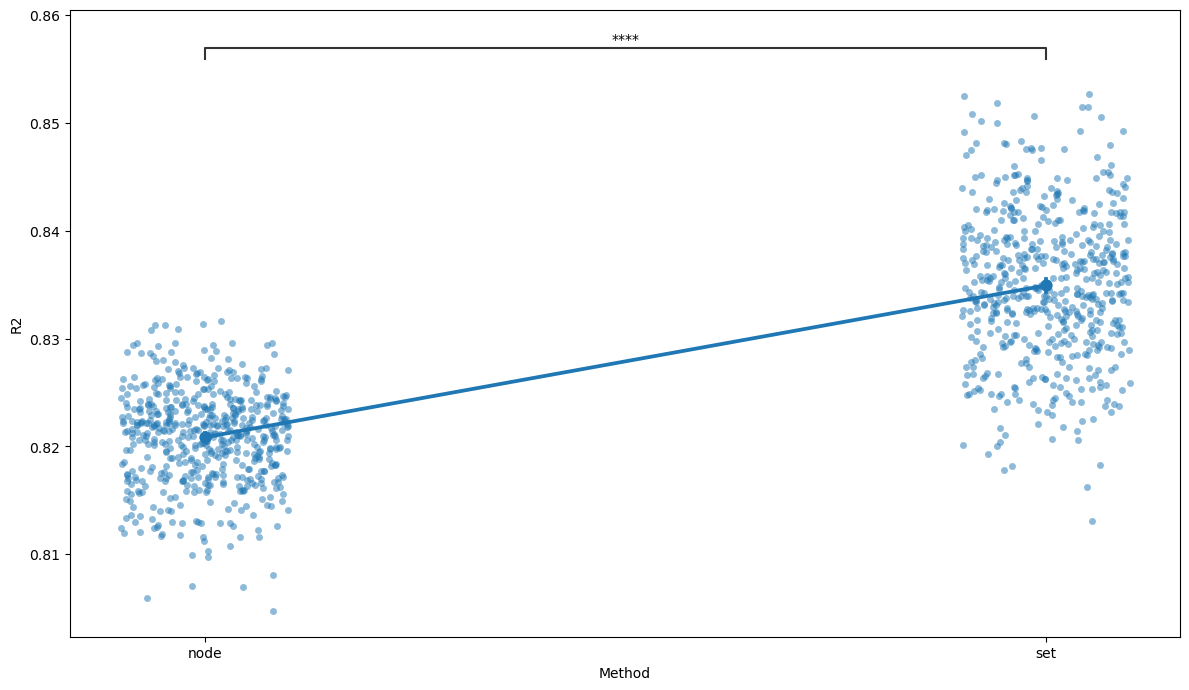

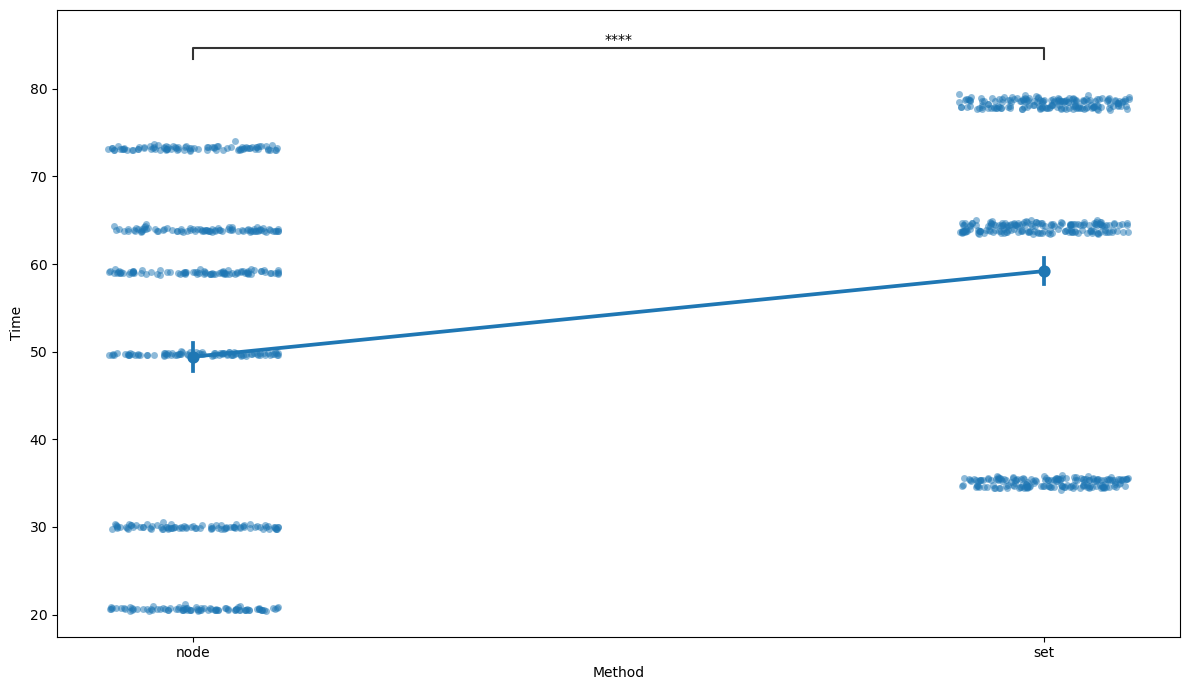

In [4]:
metric_x_point(
    df=test, 
    cols=['method'],
    # metrics=['mae'],
    figsize=(12,7),
    strip=True,
    sig=True
)

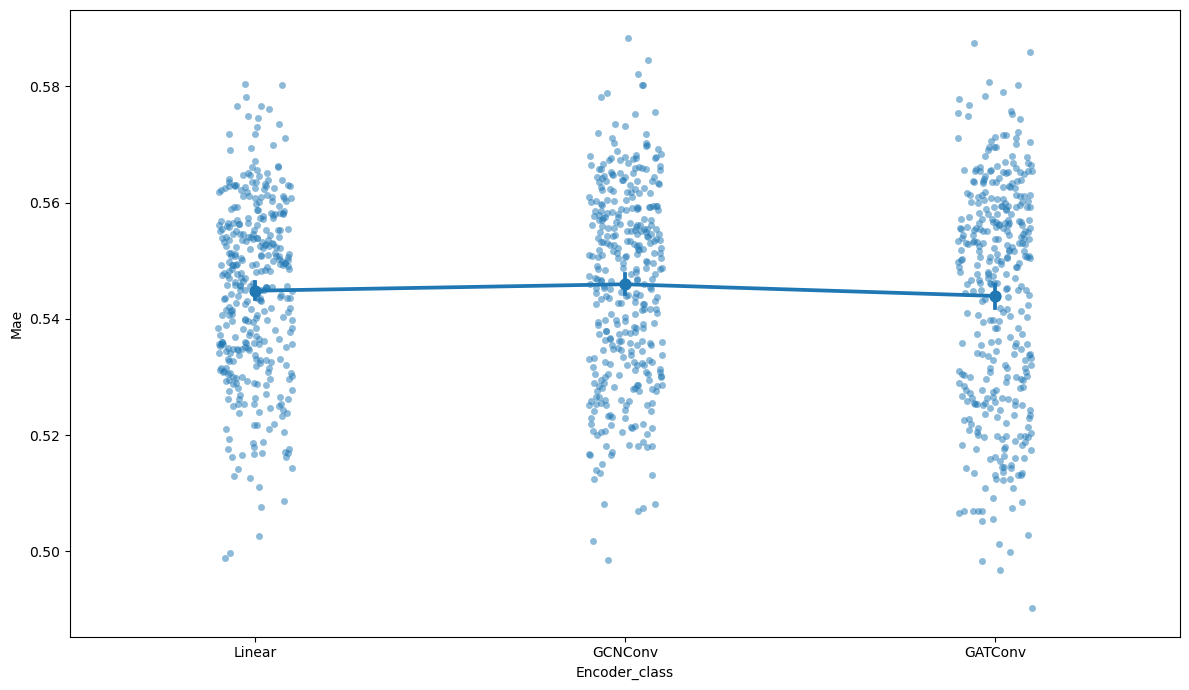

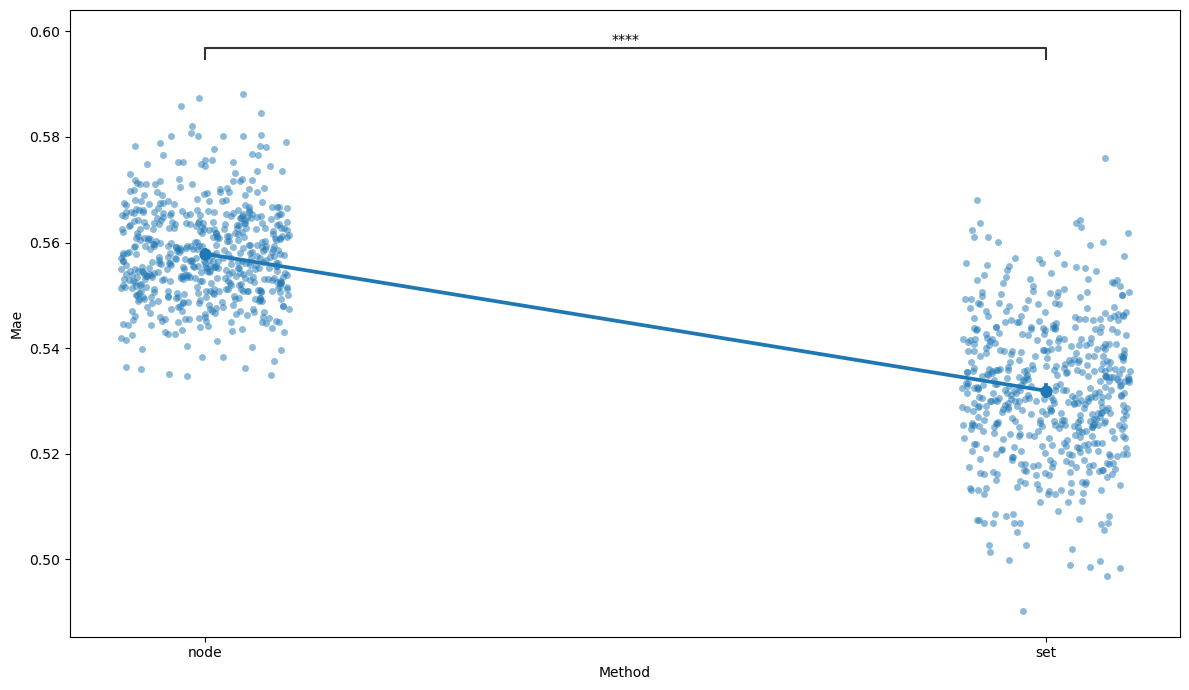

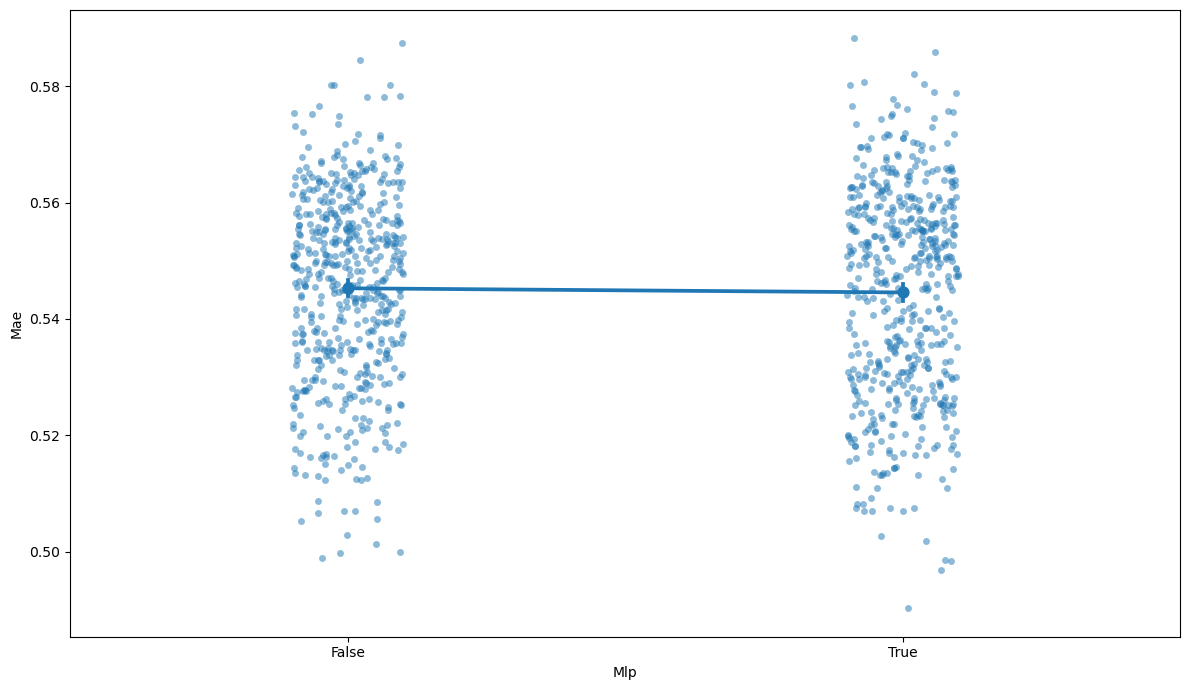

In [5]:
metric_x_point(
    df=test, 
    cols=['encoder_class','method','mlp'],
    metrics=['mae'],
    figsize=(12,7),
    strip=True,
    sig=True
)

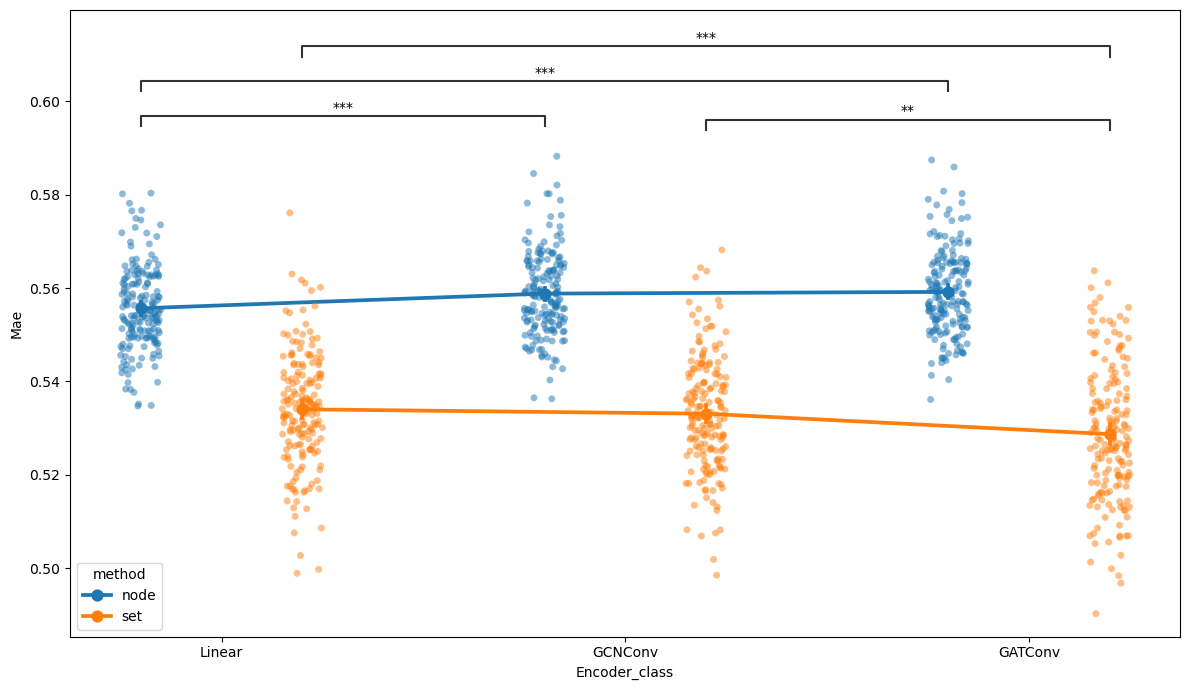

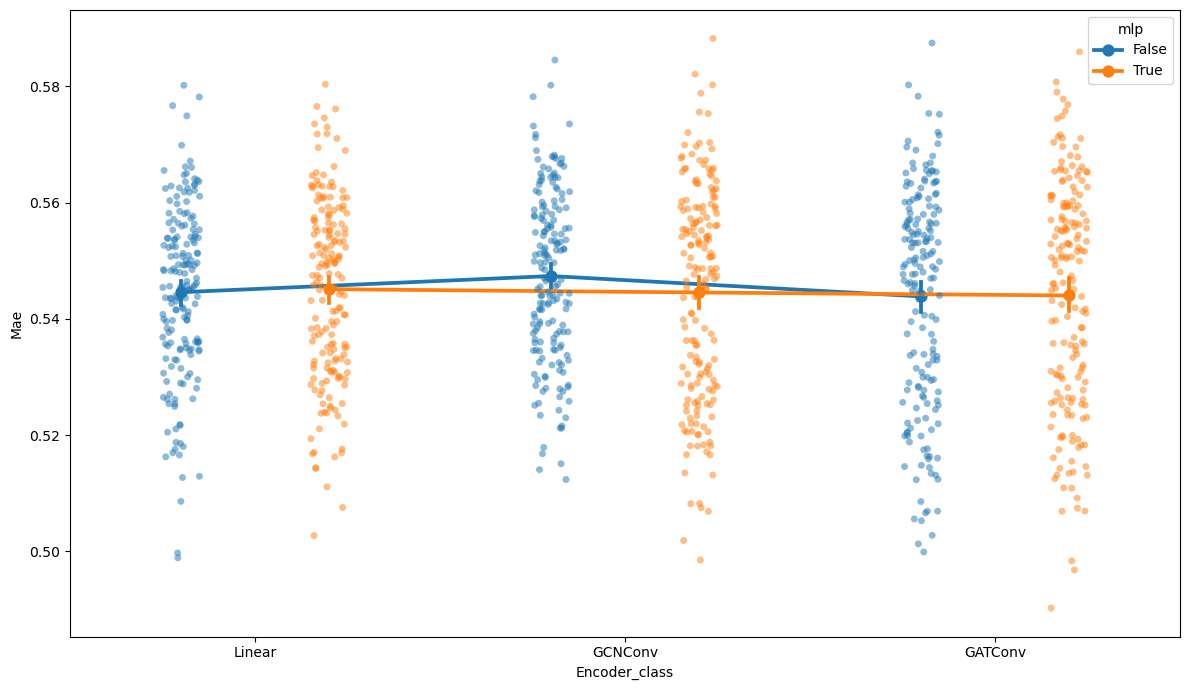

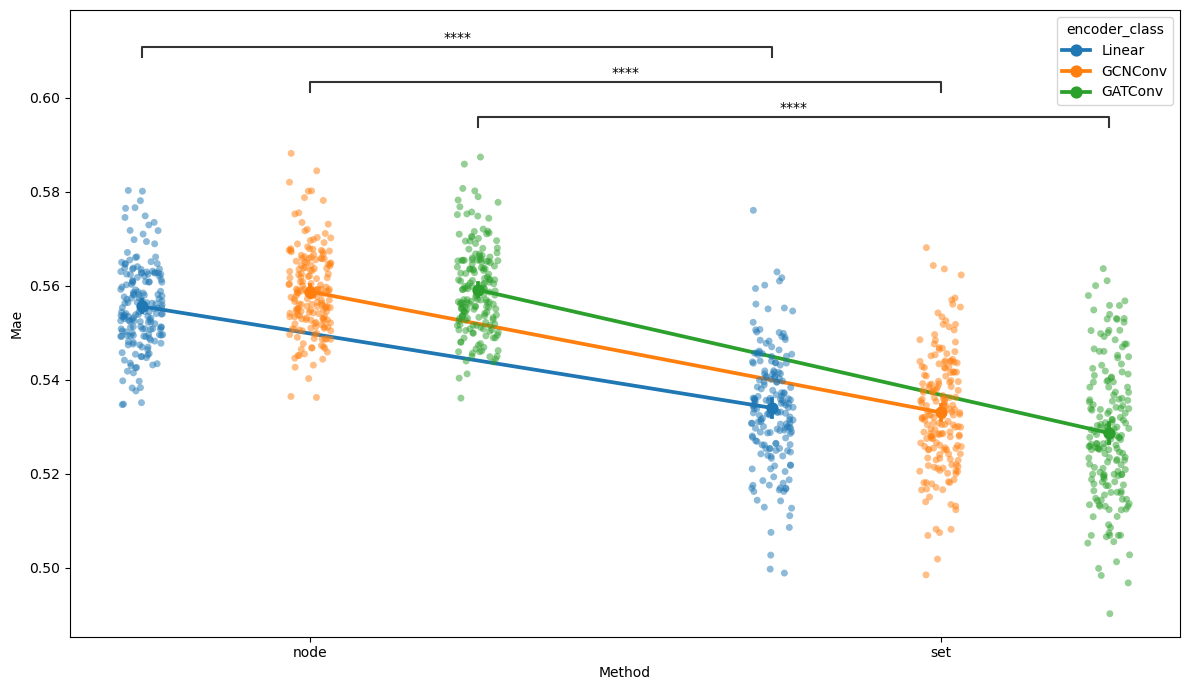

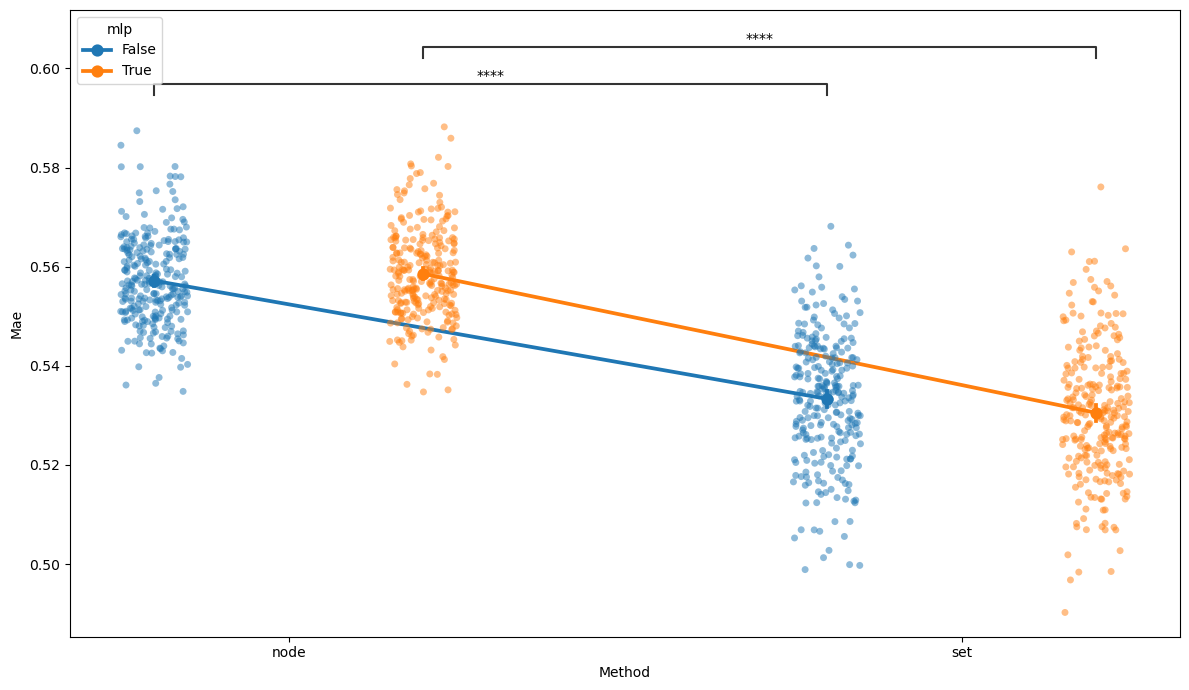

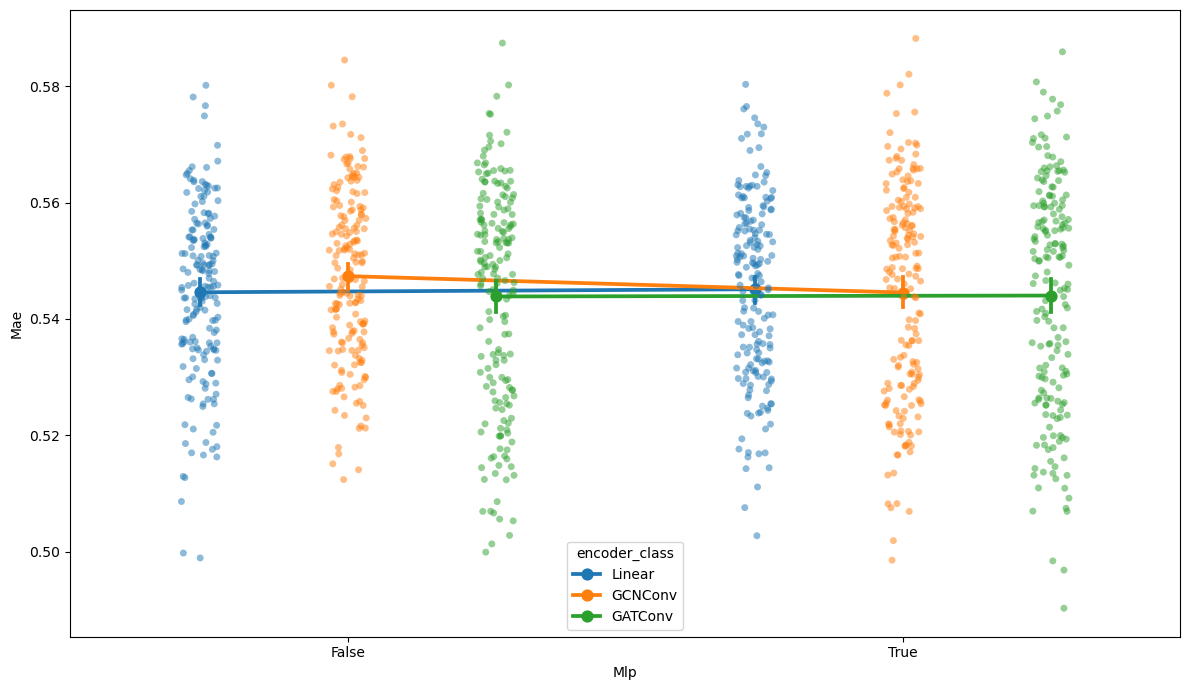

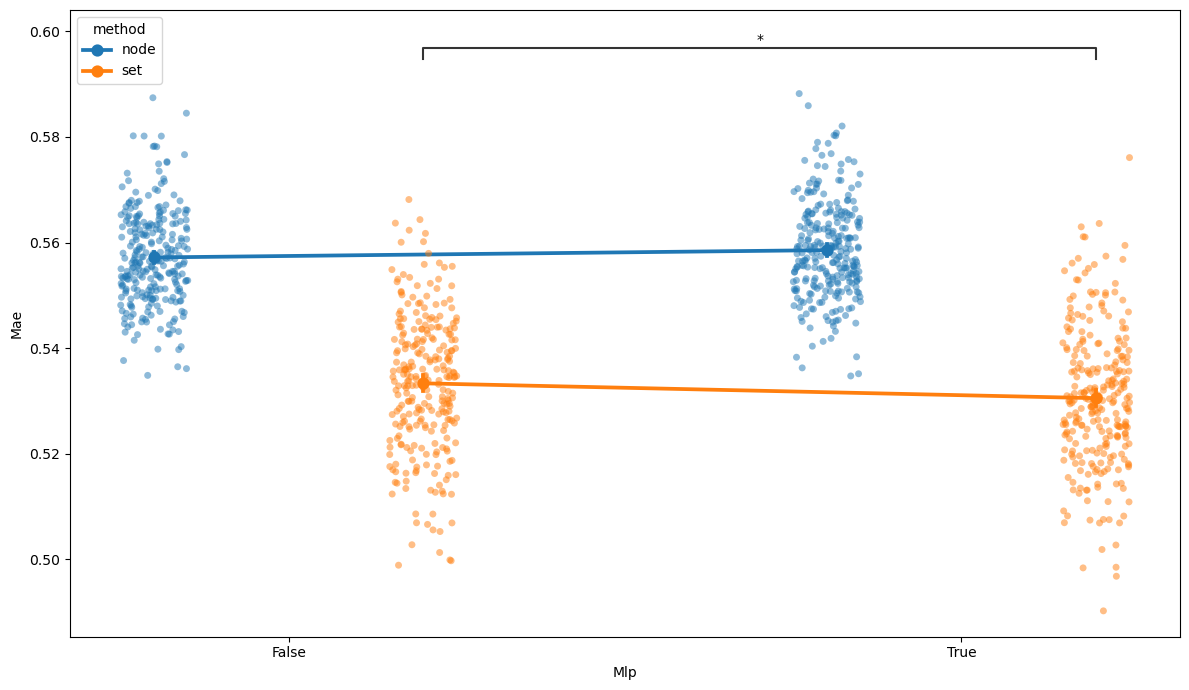

In [7]:
metric_x_point(
    df=test, 
    cols=['encoder_class','method','mlp'],
    metrics=['mae'],
    figsize=(12,7),
    strip=True,
    sig='between',
    hue=True
)